# Outlier Detection | 4DT910

Samuel Fredric Berg (sb224sc)

## AI Usage

AI has been used to make sure of text uniformity and improve graph labels.

## Imports & Config

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Loading & Initial Exploration

In [2]:
print("Fetching MAGIC Gamma Telescope dataset...")
magic_gamma_telescope = fetch_ucirepo(id=159)

X_raw = magic_gamma_telescope.data.features.copy()
y_raw = magic_gamma_telescope.data.targets.copy()

print(f"Dataset Shape: {X_raw.shape}")
print(f"Target Distribution:\n{y_raw['class'].value_counts()}")

print("\nMissing values per column:")
print(X_raw.isnull().sum())

X_raw.head()

Fetching MAGIC Gamma Telescope dataset...
Dataset Shape: (19020, 10)
Target Distribution:
class
g    12332
h     6688
Name: count, dtype: int64

Missing values per column:
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
dtype: int64


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620


## Feature Analysis, Preprocessing & Feature Scaling

### Dataset Description & Feature Selection
MAGIC Gamma Telescope simulates gamma-ray detection in an atmospheric Cherenkov telescope: $19,020$ events, $10$ continuous shower-image features (`fLength`, `fWidth`, `fSize`, `fConc`, `fConc1`, `fAsym`, `fM3Long`, `fM3Trans`, `fAlpha`, `fDist`), no missing values. Classes: gamma `g` ($12,332$, normal = $0$) and hadron `h` ($6,688$, treated as the anomaly = $1$).

All $10$ features describe shower shape/orientation, so all are kept.

**Scaling:** LOF and Elliptic Envelope are distance-based and sensitive to feature scale (`fSize`/`fLength` span hundreds of units, `fConc` is $0$–$1$), so all features are standardized with `StandardScaler`.

In [3]:
# Convert binary ground-truth labels: 'h' (Hadron / Anomaly) -> 1, 'g' (Gamma / Normal) -> 0
y_ground_truth = (y_raw['class'] == 'h').astype(int)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

print("Scaled Feature Summary Statistics:")
display(X_scaled.describe().T[['mean', 'std', 'min', '50%', 'max']])

Scaled Feature Summary Statistics:


,mean,std,min,50%,max
fLength,7.172671e-17,1.000026,-1.155862,-0.380100,6.631304
fWidth,-1.314990e-16,1.000026,-1.209064,-0.274784,12.766078
fSize,-2.211574e-16,1.000026,-1.869959,-0.180744,5.286407
fConc,1.494306e-18,1.000026,-2.008809,-0.143194,2.804429
fConc1,1.102051e-16,1.000026,-1.939745,-0.164306,4.167511
fAsym,-1.195445e-17,1.000026,-7.661315,0.140949,9.789330
fM3Long,0.000000e+00,1.000026,-6.712427,0.093503,4.466292
fM3Trans,-8.405474e-18,1.000026,-9.897993,0.019997,8.623528
fAlpha,4.781781e-17,1.000026,-1.059103,-0.381804,2.388785
fDist,-1.195445e-17,1.000026,-2.576420,-0.026316,4.037785


## Local Outlier Factor (LOF) & Neighborhood Sensitivity (`k`)


### LOF
LOF compares an observation's local density to that of its `k` nearest neighbours. A score near $1$ means similar density to its neighbours (normal); scores well above $1$ mean a sparser region, i.e. an outlier.

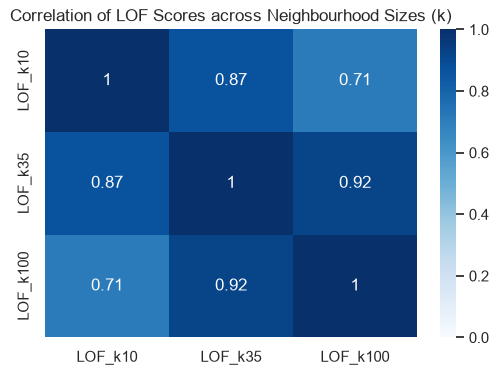

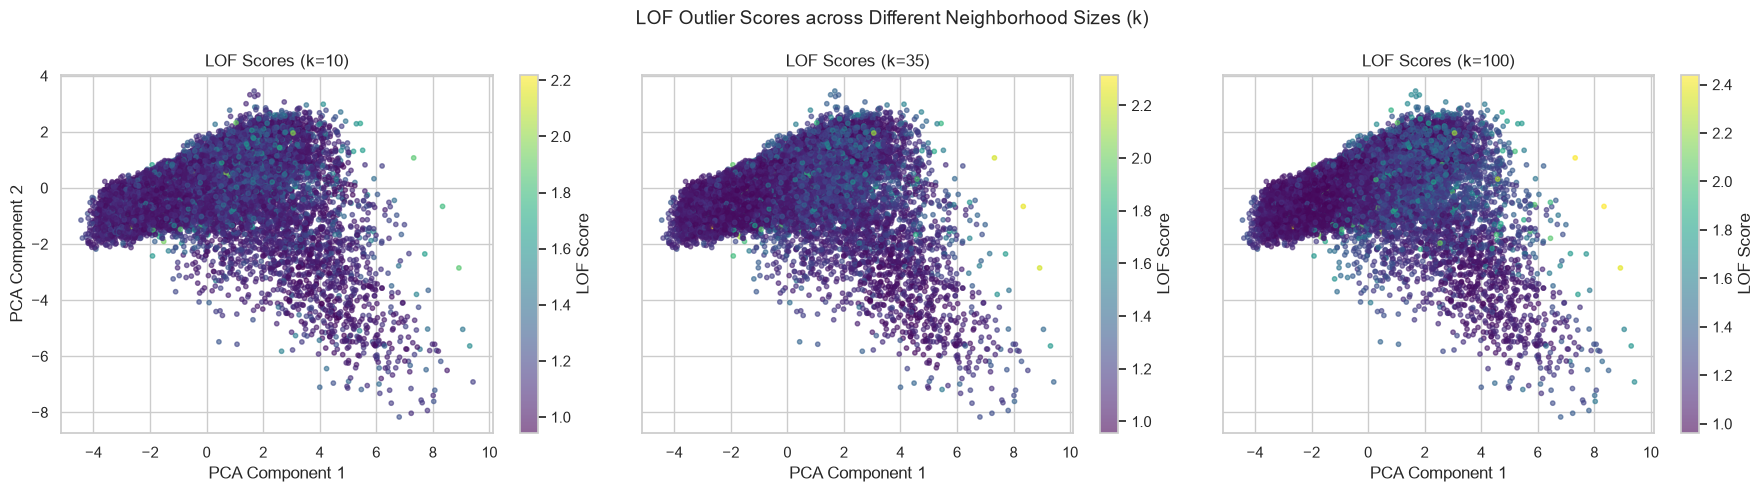

In [4]:
k_values = [10, 35, 100]
lof_scores = {}

for k in k_values:
    lof = LocalOutlierFactor(n_neighbors=k, novelty=False)
    lof.fit(X_scaled)
    
    lof_scores[f'LOF_k{k}'] = -lof.negative_outlier_factor_

lof_df = pd.DataFrame(lof_scores)

plt.figure(figsize=(6, 4))
sns.heatmap(lof_df.corr(), annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlation of LOF Scores across Neighbourhood Sizes (k)")
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, k in enumerate(k_values):
    scores = lof_scores[f'LOF_k{k}']
    sc = axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=scores, cmap='viridis', s=10, alpha=0.6)
    axes[i].set_title(f'LOF Scores (k={k})')
    axes[i].set_xlabel('PCA Component 1')
    if i == 0:
        axes[i].set_ylabel('PCA Component 2')
    plt.colorbar(sc, ax=axes[i], label='LOF Score')

plt.suptitle("LOF Outlier Scores across Different Neighborhood Sizes (k)", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import itertools

top_n = 50
top_sets = {k: set(lof_df[f'LOF_k{k}'].nlargest(top_n).index) for k in k_values}

print(f"Pairwise Jaccard overlap of top-{top_n} LOF outliers across k values:\n")
for (k1, s1), (k2, s2) in itertools.combinations(top_sets.items(), 2):
    inter = len(top_sets[k1] & top_sets[k2])
    union = len(top_sets[k1] | top_sets[k2])
    print(f"k={k1:>3} vs k={k2:>3}: {inter:>3}/{union:<3} overlap  (Jaccard = {inter/union:.2f})")

only_small_k = top_sets[k_values[0]] - top_sets[k_values[-1]]
only_large_k = top_sets[k_values[-1]] - top_sets[k_values[0]]
stable_across_k = set.intersection(*top_sets.values())

print(f"\nStable outliers (top-{top_n} at ALL k values): {len(stable_across_k)}")
print(f"Only flagged at smallest k ({k_values[0]}): {len(only_small_k)} observations")
print(f"Only flagged at largest k ({k_values[-1]}): {len(only_large_k)} observations")

print("\nExample points that drop out as k grows (unscaled features):")
display(X_raw.loc[list(only_small_k)[:5]])

print("\nExample points that only appear as outliers once k is large (unscaled features):")
display(X_raw.loc[list(only_large_k)[:5]])


Pairwise Jaccard overlap of top-50 LOF outliers across k values:

k= 10 vs k= 35:  31/69  overlap  (Jaccard = 0.45)
k= 10 vs k=100:  19/81  overlap  (Jaccard = 0.23)
k= 35 vs k=100:  31/69  overlap  (Jaccard = 0.45)

Stable outliers (top-50 at ALL k values): 19
Only flagged at smallest k (10): 31 observations
Only flagged at largest k (100): 31 observations

Example points that drop out as k grows (unscaled features):


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
8074,59.3960,20.6391,2.3927,0.5263,0.2652,-65.3947,-51.2413,-17.5809,37.8410,450.4020
12812,66.2889,8.7789,2.2625,0.5464,0.2760,54.6197,-14.8397,4.9454,6.6645,27.5502
12557,109.8893,31.9435,2.8997,0.3623,0.2007,81.8798,-100.1337,-27.3080,39.7536,379.2065
13711,60.0078,28.0342,3.1221,0.4618,0.2491,-14.0722,42.7354,-13.6216,82.9480,364.9255
1296,46.5015,36.7249,3.0881,0.2792,0.1408,7.1853,56.9306,-10.5249,19.1630,29.6676



Example points that only appear as outliers once k is large (unscaled features):


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
13202,197.0710,21.6431,2.8594,0.3815,0.2509,225.4670,-134.8910,-10.8622,62.4290,40.4893
13587,117.0030,33.1912,2.8993,0.1854,0.0927,98.6056,-65.3177,-29.7239,5.5970,217.8160
18835,184.5850,124.7150,3.7929,0.1104,0.0637,326.4010,-181.2100,-164.1400,87.3650,210.3400
16532,241.7440,65.7373,2.9307,0.3238,0.2282,339.1670,-186.4730,56.7684,89.2007,185.1610
12565,258.5767,154.4648,3.5145,0.0576,0.0460,381.2499,-181.1397,-120.4308,58.9818,184.4086


### Interpreting the Neighbourhood-Size Sensitivity

- **Stability:** only $19$ of the top-$50$ outliers ($38\%$) stay in the top-$50$ for all `k` ($10$, $35$, $100$). Jaccard overlap falls from $0.45$ (`k`=$10$ vs $35$) to $0.23$ (`k`=$10$ vs $100$), so the ranking is only moderately robust.
- **What changes:** points flagged only at `k`=$10$ have unremarkable values (e.g. `fAlpha` ≈ $6.7$–$37.8$, `fDist` ≈ $28$–$450$); they are small, tight local pockets that disappear once the neighbourhood widens. Points flagged only at `k`=$100$ are genuinely extreme (`fLength` $197$–$259$ vs mean ≈ $53$; `fAsym` $225$–$381$ vs mean ≈ $-4$); at small `k` their neighbours are equally extreme, so they only stand out against the wider bulk.
- **Which `k` fits better:** a larger `k` (≈ $100$), since it captures physically extreme observations, whereas small-`k` detections look like noise-level density fluctuations. The cost is lower sensitivity to truly local anomalies.

## Inspection of Top LOF Outliers

In [6]:
top_10_k35 = lof_df['LOF_k35'].nlargest(10).index

print("Original Unscaled Feature Values for Top 10 LOF (k=35) Outliers:")
outlier_inspection = X_raw.loc[top_10_k35].copy()
outlier_inspection['LOF_Score'] = lof_df.loc[top_10_k35, 'LOF_k35']
outlier_inspection['Class_Label'] = y_raw.loc[top_10_k35, 'class']
display(outlier_inspection)

print("\nOverall Mean Feature Values Across Dataset:")
display(X_raw.mean().to_frame().T)

Original Unscaled Feature Values for Top 10 LOF (k=35) Outliers:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,LOF_Score,Class_Label
15525,31.6496,16.4815,2.6057,0.8585,0.5878,21.9778,34.3648,21.2481,77.3860,394.4193,2.316626,h
17717,263.9140,256.3820,3.7684,0.0651,0.0326,220.4880,52.4448,-95.0139,10.3120,31.9174,2.263688,h
17619,273.4335,220.5144,3.5000,0.0645,0.0529,349.1051,140.8111,-90.3010,51.5325,162.6092,2.219447,h
17754,240.7540,228.0385,4.9050,0.0303,0.0125,198.3768,-102.5088,-205.8947,77.6662,162.6817,2.219430,h
9292,25.4947,23.1680,2.3414,0.7062,0.4032,-30.9852,18.5990,12.3783,84.7935,394.2130,2.125986,g
18278,147.9936,52.9572,3.3779,0.0868,0.0393,250.2342,2.4760,42.7271,15.4543,228.1573,2.120830,h
15127,26.4689,21.5712,2.5384,0.7786,0.3980,29.7626,2.1894,-23.7720,75.6990,402.6250,2.083862,h
17940,77.3767,19.1751,2.5128,0.5528,0.3464,91.7632,-30.6467,11.3837,18.2830,154.8265,2.045292,h
16241,54.2256,32.5475,2.8447,0.4035,0.2944,3.2803,39.1280,19.4208,0.2295,161.1010,2.030025,h
10129,84.3673,16.2703,2.6107,0.5907,0.4032,57.5241,63.4487,16.7601,12.7060,137.9160,2.016657,g



Overall Mean Feature Values Across Dataset:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026


In [7]:
feature_means = X_raw.mean()
feature_stds = X_raw.std()
z_scores = (outlier_inspection[X_raw.columns] - feature_means) / feature_stds

print("Standardized deviation (z-score) of each top-10 outlier from the dataset mean:")
display(z_scores.round(2))

print("\nFeature most responsible for each outlier's high LOF score (largest |z|):")
display(z_scores.abs().idxmax(axis=1).to_frame('most_extreme_feature'))


Standardized deviation (z-score) of each top-10 outlier from the dataset mean:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
15525,-0.51,-0.31,-0.46,2.62,3.38,0.44,0.47,1.01,1.91,2.68
17717,4.97,12.77,2.00,-1.72,-1.65,3.80,0.82,-4.57,-0.66,-2.17
17619,5.20,10.81,1.43,-1.73,-1.46,5.97,2.55,-4.35,0.92,-0.42
17754,4.43,11.22,4.40,-1.91,-1.83,3.42,-2.22,-9.90,1.92,-0.42
9292,-0.66,0.05,-1.02,1.78,1.71,-0.45,0.16,0.58,2.19,2.68
18278,2.24,1.68,1.17,-1.61,-1.59,4.30,-0.16,2.04,-0.47,0.46
15127,-0.63,-0.03,-0.61,2.18,1.66,0.58,-0.16,-1.15,1.84,2.79
17940,0.57,-0.16,-0.66,0.94,1.19,1.62,-0.81,0.53,-0.36,-0.52
16241,0.02,0.57,0.04,0.13,0.72,0.13,0.56,0.92,-1.05,-0.44
10129,0.73,-0.32,-0.45,1.15,1.71,1.04,1.04,0.79,-0.57,-0.75



Feature most responsible for each outlier's high LOF score (largest |z|):


,most_extreme_feature
15525,fConc1
17717,fWidth
17619,fWidth
17754,fWidth
9292,fDist
18278,fAsym
15127,fDist
17940,fAsym
16241,fAlpha
10129,fConc1


### Discussion: Why Were These Observations Flagged?

**Class agreement:** $8$ of the top-$10$ are Hadron (base rate $35\%$), so LOF recovers much of the class separation from geometry alone.

**Rare but valid:** indices $17717$, $17619$, $17754$ have extreme `fWidth` ($220$–$256$ vs mean $22.2$, $z ≈ 10$–$13$) and huge `fLength` (up to $273$). These are large, diffuse hadronic showers, which is physically plausible.

**Data errors:** none apparent; extreme values move together consistently (no impossible combinations such as large `fSize` with near-zero `fLength`).

**Interesting cases:** the two Gamma outliers. Index $9292$ has extreme `fDist` ($394$ vs mean $194$) with high `fAlpha` ($84.8°$), an atypical, poorly aligned gamma event. Index $10129$ has only mild deviations ($z=1.71$ on `fConc1`), flagged for an unusual *combination* of features, which is what LOF is good at.

**Expected but missed:** `fAlpha`, the key gamma/hadron discriminator, drives only one outlier (index $16241$). LOF mostly finds "big, unusual showers", so hadrons that differ mainly by large `fAlpha` may be missed.

## Multi-Algorithm Comparison (LOF, Isolation Forest, Elliptic Envelope)

### Algorithms Evaluated
1. **LOF (`k`=$35$):** flags points in much sparser neighbourhoods than their neighbours (local density).
2. **Isolation Forest (`n_estimators`=$100$):** random axis-aligned splits; anomalies are isolated in fewer splits (shorter average path).
3. **Elliptic Envelope:** fits a robust Gaussian mean/covariance and flags points with large Mahalanobis distance.

In [8]:
contamination_rate = 0.35

lof_model = LocalOutlierFactor(n_neighbors=35, contamination=contamination_rate, novelty=False)
preds_lof = lof_model.fit_predict(X_scaled)
scores_lof = -lof_model.negative_outlier_factor_

iforest = IsolationForest(n_estimators=100, contamination=contamination_rate, random_state=42)
preds_iforest = iforest.fit_predict(X_scaled)
scores_iforest = -iforest.score_samples(X_scaled)

ee = EllipticEnvelope(contamination=contamination_rate, random_state=42)
preds_ee = ee.fit_predict(X_scaled)
scores_ee = -ee.score_samples(X_scaled)

results_df = pd.DataFrame({
    'LOF_Pred': np.where(preds_lof == -1, 1, 0),
    'IForest_Pred': np.where(preds_iforest == -1, 1, 0),
    'EllipticEnvelope_Pred': np.where(preds_ee == -1, 1, 0),
    'LOF_Score': scores_lof,
    'IForest_Score': scores_iforest,
    'EllipticEnvelope_Score': scores_ee,
    'Ground_Truth': y_ground_truth
})

results_df['Total_Votes'] = results_df[['LOF_Pred', 'IForest_Pred', 'EllipticEnvelope_Pred']].sum(axis=1)

print("Outlier Detection Agreement Distribution (0 to 3 votes):")
print(results_df['Total_Votes'].value_counts().sort_index())

Outlier Detection Agreement Distribution (0 to 3 votes):
Total_Votes
0    7916
1    5127
2    3087
3    2890
Name: count, dtype: int64


In [9]:
all_three = results_df[results_df['Total_Votes'] == 3]
only_lof = results_df[(results_df.LOF_Pred == 1) & (results_df.IForest_Pred == 0) & (results_df.EllipticEnvelope_Pred == 0)]
only_iforest = results_df[(results_df.IForest_Pred == 1) & (results_df.LOF_Pred == 0) & (results_df.EllipticEnvelope_Pred == 0)]
only_ee = results_df[(results_df.EllipticEnvelope_Pred == 1) & (results_df.LOF_Pred == 0) & (results_df.IForest_Pred == 0)]

print(f"Flagged by all three methods: {len(all_three)}")
print(f"Flagged ONLY by LOF: {len(only_lof)}")
print(f"Flagged ONLY by Isolation Forest: {len(only_iforest)}")
print(f"Flagged ONLY by Elliptic Envelope: {len(only_ee)}")

for name, group in [('All three', all_three), ('Only LOF', only_lof),
                     ('Only IForest', only_iforest), ('Only EllipticEnvelope', only_ee)]:
    if len(group) > 0:
        hadron_rate = group['Ground_Truth'].mean()
        print(f"{name}: {hadron_rate:.1%} are true Hadron events (n={len(group)})")

print("\nExample raw features for points flagged ONLY by Isolation Forest:")
display(X_raw.loc[only_iforest.index[:5]])

print("\nExample raw features for points flagged ONLY by Elliptic Envelope:")
display(X_raw.loc[only_ee.index[:5]])


Flagged by all three methods: 2890
Flagged ONLY by LOF: 1844
Flagged ONLY by Isolation Forest: 1960
Flagged ONLY by Elliptic Envelope: 1323
All three: 69.4% are true Hadron events (n=2890)
Only LOF: 38.2% are true Hadron events (n=1844)
Only IForest: 31.0% are true Hadron events (n=1960)
Only EllipticEnvelope: 6.7% are true Hadron events (n=1323)

Example raw features for points flagged ONLY by Isolation Forest:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370
23,20.3836,9.0462,2.3365,0.6359,0.3894,22.2700,12.9487,-2.0403,43.0032,66.1667
43,13.2617,10.7145,2.1319,0.7823,0.4096,14.7178,2.4666,-11.8517,68.6040,107.8510
47,12.9740,10.9058,2.1021,0.7431,0.4704,13.7506,-6.2434,-6.5973,42.2408,168.2450
63,20.8112,7.1717,2.1255,0.7041,0.3558,-1.5465,8.9641,-6.0245,85.1030,235.9510



Example raw features for points flagged ONLY by Elliptic Envelope:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
10,62.7766,29.9104,3.3331,0.2475,0.1261,-33.9065,57.5848,23.7710,9.9144,323.094
21,86.0486,21.8287,3.3587,0.2369,0.1662,-58.7854,57.8212,-18.8093,2.0050,302.553
34,75.2057,31.6833,3.1334,0.1920,0.0997,-58.1243,43.0800,10.3219,1.5926,282.915
48,63.2886,26.4270,3.4434,0.2342,0.1273,-27.3566,54.6506,19.7834,0.9753,302.897
55,92.8723,25.6850,3.1553,0.2420,0.1619,-25.5033,51.7970,-19.0013,7.7301,304.585


### Discussion: Where Do the Methods Agree and Disagree?

**Consensus ($2,890$ points):** $69.4\%$ Hadron, about double the $35.2\%$ base rate, so agreement picks out genuinely unusual events.

**LOF only ($1,844$, $38.2\%$ Hadron):** near the base rate; mostly local density quirks unrelated to the class.

**Isolation Forest only ($1,960$, $31.0\%$ Hadron):** compact, high-`fConc` showers that are easy to isolate with a few splits but not locally sparse, and slightly more likely to be Gamma.

**Elliptic Envelope only ($1,323$, $6.7\%$ Hadron):** low `fAlpha` and high `fDist`, typical of well-reconstructed Gamma events that merely lie in the tail of the fitted ellipse.

**Why they disagree:** local density, isolation ease and Gaussian distance are different notions of "unusual". MAGIC is a mixture of two differently shaped populations, so Elliptic Envelopes Gaussian assumption fits worst, matching its lowest ROC-AUC.

## Visual Comparison and Parameter Sensitivity

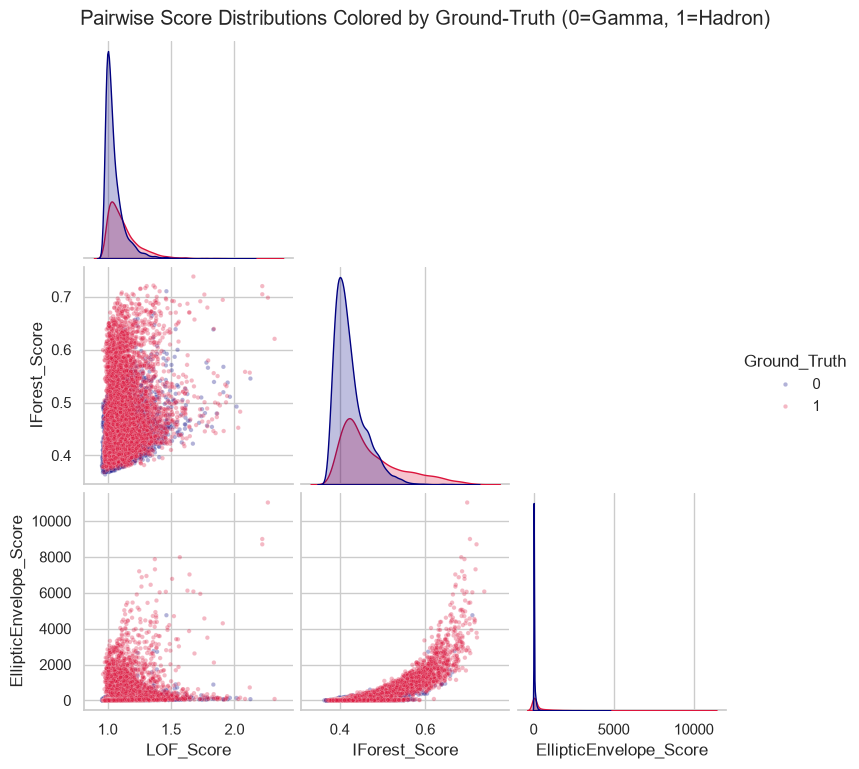

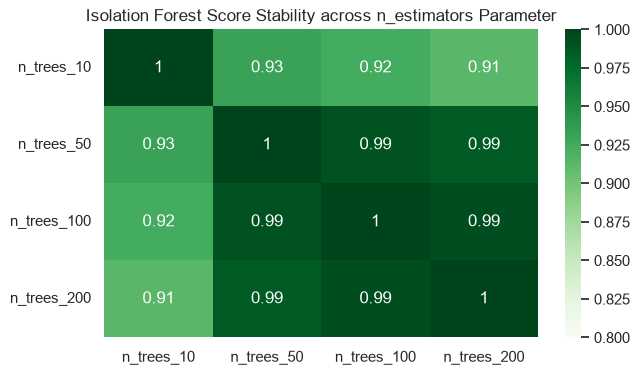

In [10]:
sns.pairplot(results_df[['LOF_Score', 'IForest_Score', 'EllipticEnvelope_Score', 'Ground_Truth']], 
             hue='Ground_Truth', palette={0: 'navy', 1: 'crimson'}, corner=True,
             plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle("Pairwise Score Distributions Colored by Ground-Truth (0=Gamma, 1=Hadron)", y=1.02)
plt.show()

n_trees = [10, 50, 100, 200]
iforest_sens = {}
for n in n_trees:
    iso = IsolationForest(n_estimators=n, contamination=contamination_rate, random_state=42)
    iso.fit(X_scaled)
    iforest_sens[f'n_trees_{n}'] = -iso.score_samples(X_scaled)

iforest_sens_df = pd.DataFrame(iforest_sens)

plt.figure(figsize=(7, 4))
sns.heatmap(iforest_sens_df.corr(), annot=True, cmap="Greens", vmin=0.8, vmax=1.0)
plt.title("Isolation Forest Score Stability across n_estimators Parameter")
plt.show()

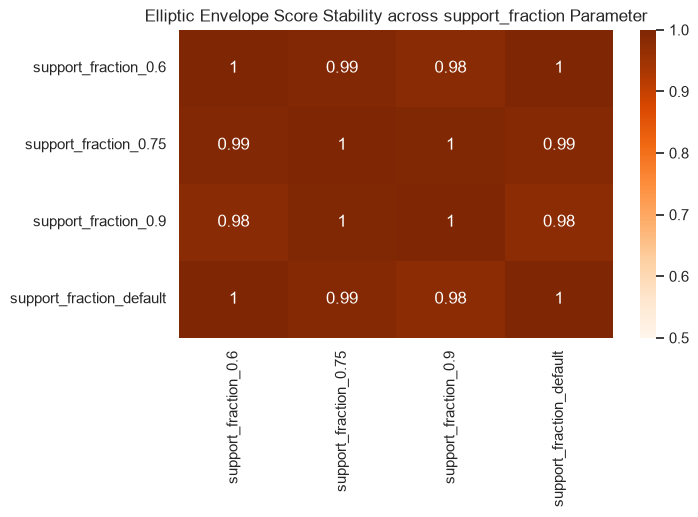

In [11]:
support_fractions = [0.6, 0.75, 0.9, None]
ee_sens = {}
for sf in support_fractions:
    ee_p = EllipticEnvelope(contamination=contamination_rate, support_fraction=sf, random_state=42)
    ee_p.fit(X_scaled)
    label = sf if sf is not None else 'default'
    ee_sens[f'support_fraction_{label}'] = -ee_p.score_samples(X_scaled)

ee_sens_df = pd.DataFrame(ee_sens)

plt.figure(figsize=(7, 4))
sns.heatmap(ee_sens_df.corr(), annot=True, cmap="Oranges", vmin=0.5, vmax=1.0)
plt.title("Elliptic Envelope Score Stability across support_fraction Parameter")
plt.show()


### Why These Parameters Change the Results

**Isolation Forest `n_estimators`:** score correlation is $0.91$–$0.93$ at $10$ trees and ≥ $0.99$ from $50$ trees. More trees average out random splits, so the ranking stabilizes, but the *kind* of point deemed anomalous does not change.

**Elliptic Envelope `support_fraction`:** correlations stay at $0.98$–$1.00$, so the robust covariance fit is insensitive to it here. Its weak performance therefore comes from the wrong Gaussian assumption, not an unstable fit.

**LOF `n_neighbors`** (above): sets the scale of "local"; small `k` finds micro-clusters, large `k` compares against a broader neighbourhood.

In short: Isolation Forest converges quickly, Elliptic Envelope is stable but mismatched to the data, and LOF is the most sensitive to its main parameter.

## Quantitative Evaluation & Final Decision

### A Caveat on `contamination` = $0.35$

`contamination` is set to the true hadron share ($35\%$) so predicted labels are comparable to the ground truth. In a real unsupervised setting this share is unknown, and $35\%$ is far above the typical $<10\%$, so this is closer to separating two populations than finding rare anomalies. **ROC-AUC** uses the continuous scores and is unaffected by `contamination`; **precision/recall/F1** depend on it. Re-running with e.g. $0.1$ should shift precision/recall but not the AUC ranking.

Quantitative Evaluation against Ground-Truth Hadron ('h') Labels

Method: LOF
ROC-AUC Score: 0.7084
                  precision    recall  f1-score   support

  Gamma (Signal)       0.75      0.76      0.75     12332
Hadron (Anomaly)       0.55      0.54      0.55      6688

        accuracy                           0.68     19020
       macro avg       0.65      0.65      0.65     19020
    weighted avg       0.68      0.68      0.68     19020


Method: IForest
ROC-AUC Score: 0.7299
                  precision    recall  f1-score   support

  Gamma (Signal)       0.76      0.76      0.76     12332
Hadron (Anomaly)       0.55      0.55      0.55      6688

        accuracy                           0.68     19020
       macro avg       0.65      0.65      0.65     19020
    weighted avg       0.68      0.68      0.68     19020


Method: EllipticEnvelope
ROC-AUC Score: 0.6978
                  precision    recall  f1-score   support

  Gamma (Signal)       0.73      0.73      0.73     

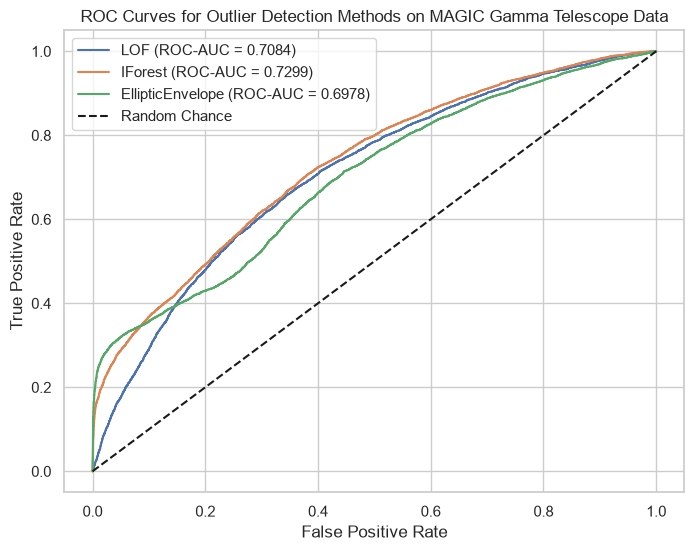

In [12]:
methods = ['LOF', 'IForest', 'EllipticEnvelope']
plt.figure(figsize=(8, 6))

print("Quantitative Evaluation against Ground-Truth Hadron ('h') Labels")

for method in methods:
    pred_col = f'{method}_Pred'
    score_col = f'{method}_Score'
    
    auc = roc_auc_score(results_df['Ground_Truth'], results_df[score_col])
    fpr, tpr, _ = roc_curve(results_df['Ground_Truth'], results_df[score_col])
    
    plt.plot(fpr, tpr, label=f'{method} (ROC-AUC = {auc:.4f})')
    
    print(f"\nMethod: {method}")
    print(f"ROC-AUC Score: {auc:.4f}")
    print(classification_report(results_df['Ground_Truth'], results_df[pred_col], 
                                target_names=['Gamma (Signal)', 'Hadron (Anomaly)']))

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Outlier Detection Methods on MAGIC Gamma Telescope Data')
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import precision_recall_fscore_support

c_low = 0.1
models_low = {
    'LOF': LocalOutlierFactor(n_neighbors=35, contamination=c_low, novelty=False),
    'IForest': IsolationForest(n_estimators=100, contamination=c_low, random_state=42),
    'EllipticEnvelope': EllipticEnvelope(contamination=c_low, random_state=42),
}

rows = []
for name, model in models_low.items():
    preds = np.where(model.fit_predict(X_scaled) == -1, 1, 0)
    auc_low = roc_auc_score(results_df['Ground_Truth'], results_df[f'{name}_Score'])  # scores from the 0.35 run
    p, r, f, _ = precision_recall_fscore_support(y_ground_truth, preds, average='binary', zero_division=0)
    p35, r35, f35, _ = precision_recall_fscore_support(
        y_ground_truth, results_df[f'{name}_Pred'], average='binary', zero_division=0)
    rows.append({'Method': name, 'ROC-AUC': round(auc_low, 4),
                 'Precision@0.35': round(p35, 2), 'Precision@0.1': round(p, 2),
                 'Recall@0.35': round(r35, 2), 'Recall@0.1': round(r, 2),
                 'F1@0.35': round(f35, 2), 'F1@0.1': round(f, 2)})

display(pd.DataFrame(rows).set_index('Method'))

,ROC-AUC,Precision@0.35,Precision@0.1,Recall@0.35,Recall@0.1,F1@0.35,F1@0.1
Method,,,,,,,
LOF,0.7084,0.55,0.65,0.54,0.19,0.55,0.29
IForest,0.7299,0.55,0.83,0.55,0.24,0.55,0.37
EllipticEnvelope,0.6978,0.49,0.91,0.49,0.26,0.49,0.40


### Outlier Technique Decision & Justification

1. **Performance:**
   - **Isolation Forest:** best, ROC-AUC $0.7299$, precision/recall/F1 $0.55$.
   - **LOF:** second, ROC-AUC $0.7084$, F1 $0.55$.
   - **Elliptic Envelope:** worst, ROC-AUC $0.6978$, F1 $0.49$.

2. **Why:** hadron showers are diffuse, asymmetric and broad, giving non-linear, non-Gaussian structure in $10$ dimensions. Isolation Forest handles this well with random splits; LOF is somewhat diluted by density estimation in $10$ dimensions; Elliptic Envelope assumes a single Gaussian, which doesn't fit this multi-modal data.

3. **Recommendation:** **Isolation Forest.** It gives the best ranking of hadron background versus gamma signal, and it is stable with respect to its parameters.